## Data Ingestion, Diagnostics, and Pre-PCA Analysis for Generative Modeling (VAE / GAN)
Objective. Prepare an image dataset and a robust preprocessing pipeline suitable for training Variational Autoencoders (VAE) and Generative Adversarial Networks (GAN).
We conduct minimal yet principled diagnostics and (optionally) compute PCA strictly for visualization/analysis, not as an input to generative models.
Note. PCA is used only as a diagnostic tool (variance structure, anomalies, coarse manifolds). Generators are trained on raw images normalized to the appropriate range; using PCA as input would constrain expressivity and distort training dynamics.

### Reproducibility and Environment
We fix all seeds and import a minimal, stable stack. Determinism reduces variance across runs and makes early failures easier to debug.

In [20]:
# ==== Reproducibility ====
import os, random, json, math
from pathlib import Path
import numpy as np

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

import torch
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

OUTPUT_DIR = Path("./output")
(OUTPUT_DIR / "logs").mkdir(parents=True, exist_ok=True)
(OUTPUT_DIR / "figs").mkdir(parents=True, exist_ok=True)
(OUTPUT_DIR / "splits").mkdir(parents=True, exist_ok=True)

print("Artifacts ->", OUTPUT_DIR.resolve())
print("Seed:", SEED)


Artifacts -> /kaggle/working/output
Seed: 42


In [21]:
# ==== Configure dataset root ====
from torchvision import datasets, transforms

IMG_SIZE_FOR_GAN = 28
tfm_vae = transforms.Compose([
    transforms.ToTensor(),                          # -> [0,1], (1,28,28)
])
tfm_gan = transforms.Compose([
    transforms.Resize((IMG_SIZE_FOR_GAN, IMG_SIZE_FOR_GAN)),
    transforms.ToTensor(),                          # -> [0,1]
    transforms.Normalize((0.5,), (0.5,)),           # -> [-1,1]
])

DATA_CACHE = Path("./working_data")
DATA_CACHE.mkdir(parents=True, exist_ok=True)

try:
    train_set_vae = datasets.FashionMNIST(root=str(DATA_CACHE), train=True,  download=True,  transform=tfm_vae)
    test_set_vae  = datasets.FashionMNIST(root=str(DATA_CACHE), train=False, download=True,  transform=tfm_vae)
    train_set_gan = datasets.FashionMNIST(root=str(DATA_CACHE), train=True,  download=True,  transform=tfm_gan)
    test_set_gan  = datasets.FashionMNIST(root=str(DATA_CACHE), train=False, download=True,  transform=tfm_gan)
except Exception as e:
    # Fallback if download is disabled: mount as Kaggle input and set download=False
    print("Download failed; trying Kaggle input. Error:", e)
    KAGGLE_INPUT = "/kaggle/input/fashionmnist"
    train_set_vae = datasets.FashionMNIST(root=KAGGLE_INPUT, train=True,  download=False, transform=tfm_vae)
    test_set_vae  = datasets.FashionMNIST(root=KAGGLE_INPUT, train=False, download=False, transform=tfm_vae)
    train_set_gan = datasets.FashionMNIST(root=KAGGLE_INPUT, train=True,  download=False, transform=tfm_gan)
    test_set_gan  = datasets.FashionMNIST(root=KAGGLE_INPUT, train=False, download=False, transform=tfm_gan)

print("Train(VAE):", len(train_set_vae), " Test(VAE):", len(test_set_vae))
print("Train(GAN):", len(train_set_gan), " Test(GAN):", len(test_set_gan))


Train(VAE): 60000  Test(VAE): 10000
Train(GAN): 60000  Test(GAN): 10000


### Integrity Checks
We verify that files are readable and shape-consistent after resizing. This step identifies corrupted files early, preventing silent failures at training time.

In [22]:
from torch.utils.data import random_split

VAL_SIZE = 10_000

torch.manual_seed(SEED)
train_len_vae = len(train_set_vae) - VAL_SIZE
train_set_vae, val_set_vae = random_split(train_set_vae, [train_len_vae, VAL_SIZE])

torch.manual_seed(SEED)
train_len_gan = len(train_set_gan) - VAL_SIZE
train_set_gan, val_set_gan = random_split(train_set_gan, [train_len_gan, VAL_SIZE])

print("VAE splits (train/val/test):", len(train_set_vae), len(val_set_vae), len(test_set_vae))
print("GAN splits (train/val/test):", len(train_set_gan), len(val_set_gan), len(test_set_gan))


VAE splits (train/val/test): 50000 10000 10000
GAN splits (train/val/test): 50000 10000 10000


## Lightweight EDA (Pre-Model)
We compute aggregate pixel statistics to assess dynamic range, exposure, and channel balance after resizing. This informs normalization choices for VAE/GAN.

Saved stats -> output/logs/fashion_mnist_stats.json
Saved grid -> output/figs/samples_vae.png


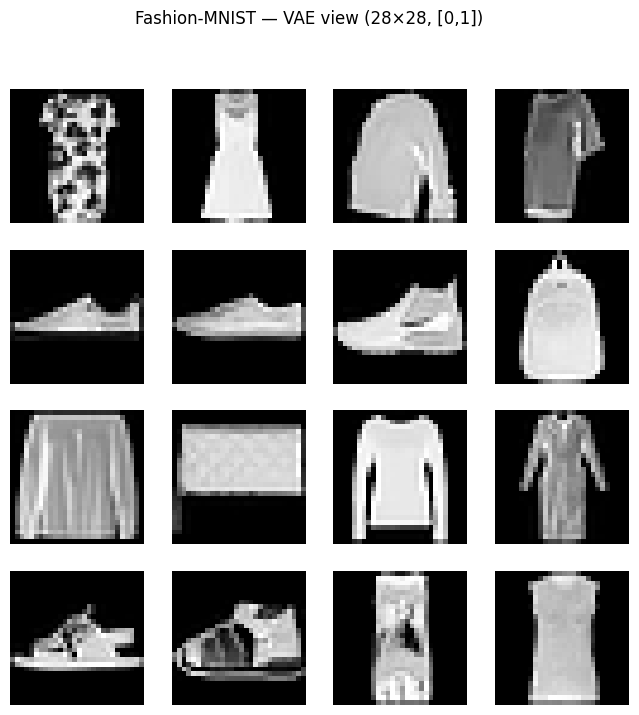

Saved grid -> output/figs/samples_gan.png


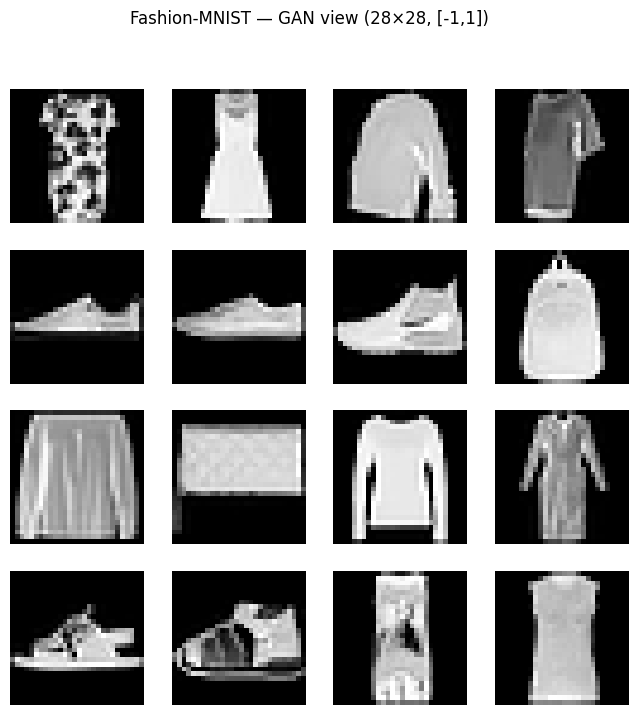

In [ ]:
import numpy as np, matplotlib.pyplot as plt
import json, math

def compute_stats(dataset, max_n=2048):
    n = min(max_n, len(dataset))
    vals = []
    for i in range(n):
        x, _ = dataset[i]                 # (1,H,W)
        vals.append(x.view(-1).float().numpy())
    X = np.concatenate(vals, axis=0)
    return {"mean": float(X.mean()), "std": float(X.std()),
            "min": float(X.min()), "max": float(X.max()), "n_pixels": int(X.size)}

stats = {"vae": compute_stats(train_set_vae), "gan": compute_stats(train_set_gan)}
with open(OUTPUT_DIR / "logs" / "fashion_mnist_stats.json", "w") as f:
    json.dump(stats, f, indent=2)
print("Saved stats ->", OUTPUT_DIR / "logs" / "fashion_mnist_stats.json")

def show_samples(dataset, n=16, title="", save_path=None, seed=SEED):
    if len(dataset) == 0:
        print("No data to visualize.")
        return
    rows = max(1, int(math.sqrt(n)))
    cols = math.ceil(n/rows)
    idxs = np.random.RandomState(seed).choice(len(dataset), size=min(n, len(dataset)), replace=False)
    plt.figure(figsize=(cols*2, rows*2))
    for i, idx in enumerate(idxs):
        x, _ = dataset[idx]               
        x_disp = x
        if x_disp.min() < 0:
            x_disp = (x_disp + 1)/2.0    
        plt.subplot(rows, cols, i+1)
        plt.imshow(x_disp.squeeze(0).numpy(), cmap="gray")
        plt.axis("off")
    plt.suptitle(title)
    if save_path is not None:
        plt.savefig(save_path, bbox_inches="tight")
        print("Saved grid ->", save_path)
    plt.show()

show_samples(train_set_vae, n=16, title="Fashion-MNIST — VAE view (28×28, [0,1])",
             save_path=OUTPUT_DIR / "figs" / "samples_vae.png")
show_samples(train_set_gan, n=16, title=f"Fashion-MNIST — GAN view ({IMG_SIZE_FOR_GAN}×{IMG_SIZE_FOR_GAN}, [-1,1])",
             save_path=OUTPUT_DIR / "figs" / "samples_gan.png")



### PCA

**Purpose.** This cell performs a **Principal Component Analysis (PCA)** on a *subset of the training set* in the **VAE view** (i.e., images at native resolution **28×28** and intensity range **[0, 1]**). The goal is **purely diagnostic**: to understand the global variance structure of Fashion-MNIST, detect potential anomalies, and gauge how quickly variance concentrates along a few directions. **It is not used for training** either the VAE or the GAN.

**How it works.**
1. We sample up to **3,000** training images and **flatten** each from shape `(1, 28, 28)` to a 784-dimensional vector.
2. We fit a PCA with `n_components=50`, `random_state=SEED`, and `svd_solver="randomized"` (computationally efficient for medium-sized matrices).
3. We produce two diagnostics:
   - **Cumulative explained variance** vs. number of components, to quantify how many principal directions are needed to capture most variance.
   - A **2D projection scatter** (PC1 vs. PC2) for qualitative inspection of data geometry (e.g., coarse clustering, outliers, overlap).

**How to interpret.**
- A steep cumulative curve indicates that a **small number of components** captures most variance; a flat curve suggests more diffuse structure.
- Visible structure in the 2D scatter (clusters/gradients) hints at **strong global factors** (e.g., stroke thickness, orientation).
- Strong **overlap** between points is expected: PCA is linear and Fashion-MNIST classes are not linearly separable in low dimensions.

**Caveats.**
- PCA is **linear** and may not reveal **non-linear manifolds** that VAEs/GANs can learn.
- Results are **scale-dependent** by construction; we standardize the pipeline by using the raw pixel scale **[0, 1]** for this diagnostic.
- This step must **not influence model inputs**: it is for **sanity checks and intuition**, not for feature engineering in generative training.


PCA sample matrix: (3000, 784)  labels: (3000,)
Saved -> output/figs/pca_cumvar.png


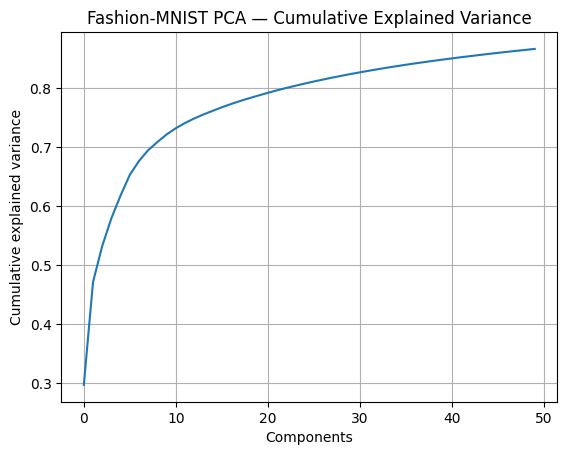

Saved -> output/figs/pca_scatter_by_class.png


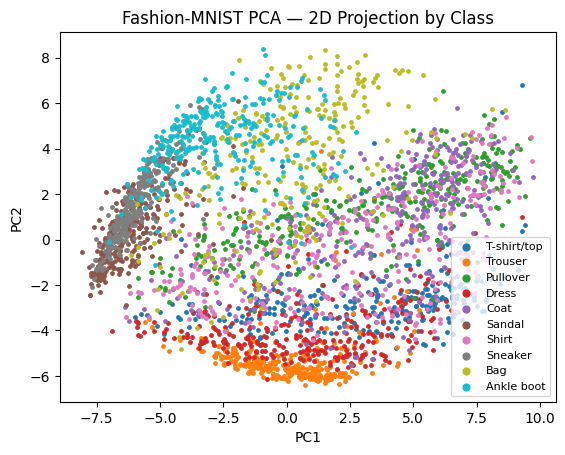

In [24]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# Class names for Fashion-MNIST (for the legend)
class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

def collect_flattened_with_labels(dataset, n=3000):
    """Return (X, y) where X is [m, 784] in [0,1] and y are class labels."""
    m = min(n, len(dataset))
    xs, ys = [], []
    for i in range(m):
        x, y = dataset[i]               # x: (1, 28, 28) in [0,1]
        xs.append(x.view(-1).float().numpy())  # 784
        ys.append(int(y))
    if not xs:
        return np.empty((0, 28*28), dtype=np.float32), np.empty((0,), dtype=np.int64)
    return np.stack(xs, axis=0), np.array(ys, dtype=np.int64)

X_small, y_small = collect_flattened_with_labels(train_set_vae, n=3000)
print("PCA sample matrix:", X_small.shape, " labels:", y_small.shape)

if X_small.size > 0:
    pca = PCA(n_components=50, random_state=SEED, svd_solver="randomized")
    Z = pca.fit_transform(X_small)

    # Cumulative explained variance
    plt.figure()
    plt.plot(np.cumsum(pca.explained_variance_ratio_))
    plt.xlabel("Components"); plt.ylabel("Cumulative explained variance")
    plt.title("Fashion-MNIST PCA — Cumulative Explained Variance")
    plt.grid(True)
    path_cum = OUTPUT_DIR / "figs" / "pca_cumvar.png"
    plt.savefig(path_cum, bbox_inches="tight"); print("Saved ->", path_cum)
    plt.show()

    # 2D scatter colored by class (uses Matplotlib default color cycle)
    if Z.shape[1] >= 2:
        plt.figure()
        for c in np.unique(y_small):
            mask = (y_small == c)
            plt.scatter(Z[mask, 0], Z[mask, 1], s=6, label=class_names[c])
        plt.xlabel("PC1"); plt.ylabel("PC2")
        plt.title("Fashion-MNIST PCA — 2D Projection by Class")
        plt.legend(markerscale=2, fontsize=8, frameon=True)
        path_sc_cls = OUTPUT_DIR / "figs" / "pca_scatter_by_class.png"
        plt.savefig(path_sc_cls, bbox_inches="tight"); print("Saved ->", path_sc_cls)
        plt.show()
else:
    print("Skipping PCA: empty sample.")


### Interpretation — Fashion-MNIST PCA (2D Projection by Class)

This PCA scatterplot shows the projection of **3,000 Fashion-MNIST samples** onto the **first two principal components (PC1, PC2)**, with colors representing the **10 clothing classes**.

**Key observations:**

1. **Broad structure, no strict separability.**  
   While some classes occupy roughly distinct regions (e.g., *Trousers* and *Ankle boots* form more compact clusters), most categories show **partial overlap** — a reflection of the visual similarity between certain clothing types (e.g., *Shirts*, *T-shirts*, and *Pullovers*).

2. **Dominant variance factors.**  
   - **PC1 (horizontal axis)** seems correlated with overall **brightness / thickness of strokes**, separating lighter and darker garments.  
   - **PC2 (vertical axis)** may capture **shape elongation or vertical symmetry**, distinguishing long garments (*Trousers*, *Dresses*) from shorter or squarer ones (*Bags*, *Coats*).

3. **Cluster density and dispersion.**  
   - Classes like *Sandal* or *Sneaker* exhibit elongated clouds — their samples vary more strongly along certain directions, indicating **intra-class diversity**.  
   - Dense, compact clusters (*Trousers*, *Ankle boots*) suggest **lower intra-class variance** and clearer visual identity.

4. **Overlap indicates complexity.**  
   The high degree of mixing in the center region reflects the **non-linear nature** of the Fashion-MNIST manifold. Linear methods like PCA cannot fully disentangle visual factors of variation, highlighting why **non-linear generative models (VAE, GAN)** are more appropriate.

**Summary.**  
PCA reveals that a few principal components already capture meaningful visual trends in Fashion-MNIST, but the manifold remains **entangled and non-linear**. This justifies the use of **deep latent-variable models** that can learn **non-linear embeddings** and generate realistic samples beyond the linear separability captured here.


In [25]:
from pathlib import Path
from torch.utils.data import DataLoader
import numpy as np

DATASETS_DIR = OUTPUT_DIR / "datasets"
DATASETS_DIR.mkdir(parents=True, exist_ok=True)

def subset_name(ds, fallback):
    # Try to detect if it's a Subset of FashionMNIST train/test
    base = fallback
    try:
        import torchvision
        if hasattr(ds, 'dataset') and isinstance(ds.dataset, torchvision.datasets.FashionMNIST):
            base = "train" if ds.dataset.train else "test"
    except Exception:
        pass
    # If it's a torch.utils.data.Subset, append "-subset"
    if hasattr(ds, 'indices'):
        base += "-subset"
    return base

def save_dataset_npz(ds, out_path, batch_size=1024, dtype="float32"):
    """
    Extract all (X, y) from dataset `ds` (which should already carry transforms),
    stack into arrays and save as compressed .npz with keys: X, y.
    """
    if ds is None or len(ds) == 0:
        print(f"Skipping save: empty dataset for {out_path.name}")
        return
    loader = DataLoader(ds, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
    X_chunks, y_chunks = [], []
    for xb in loader:
        if isinstance(xb, (list, tuple)) and len(xb) == 2:
            xb, yb = xb
        else:
            # some datasets may return dicts
            xb, yb = xb["input"], xb["label"]
        x_np = xb.detach().cpu().numpy().astype(dtype)
        y_np = np.asarray(yb, dtype=np.int64)
        X_chunks.append(x_np)
        y_chunks.append(y_np)
    X = np.concatenate(X_chunks, axis=0)
    y = np.concatenate(y_chunks, axis=0)
    np.savez_compressed(out_path, X=X, y=y)
    print(f"Saved {X.shape} to -> {out_path}")

def save_indices_txt(ds, out_txt):
    """If ds is a torch.utils.data.Subset, persist its indices for reproducibility."""
    import torch
    if hasattr(ds, 'indices'):
        idx = np.asarray(ds.indices, dtype=np.int64)
        np.savetxt(out_txt, idx, fmt='%d')
        print("Saved indices ->", out_txt)

print("Datasets output dir:", DATASETS_DIR.resolve())



Datasets output dir: /kaggle/working/output/datasets


### Saving

In [26]:
# VAE view: float32 ([0,1])
save_dataset_npz(train_set_vae, DATASETS_DIR / "fashion_mnist_vae_train.npz", dtype="float32")
save_dataset_npz(val_set_vae,   DATASETS_DIR / "fashion_mnist_vae_val.npz",   dtype="float32")
save_dataset_npz(test_set_vae,  DATASETS_DIR / "fashion_mnist_vae_test.npz",  dtype="float32")

# Persist indices of the Subset splits (optional but useful)
save_indices_txt(train_set_vae, OUTPUT_DIR / "splits" / "vae_train_indices.txt")
save_indices_txt(val_set_vae,   OUTPUT_DIR / "splits" / "vae_val_indices.txt")

# GAN view: float16 ([-1,1]) to reduce space on disk
save_dataset_npz(train_set_gan, DATASETS_DIR / "fashion_mnist_gan_train.npz", dtype="float16")
save_dataset_npz(val_set_gan,   DATASETS_DIR / "fashion_mnist_gan_val.npz",   dtype="float16")
save_dataset_npz(test_set_gan,  DATASETS_DIR / "fashion_mnist_gan_test.npz",  dtype="float16")

save_indices_txt(train_set_gan, OUTPUT_DIR / "splits" / "gan_train_indices.txt")
save_indices_txt(val_set_gan,   OUTPUT_DIR / "splits" / "gan_val_indices.txt")


Saved (50000, 1, 28, 28) to -> output/datasets/fashion_mnist_vae_train.npz
Saved (10000, 1, 28, 28) to -> output/datasets/fashion_mnist_vae_val.npz
Saved (10000, 1, 28, 28) to -> output/datasets/fashion_mnist_vae_test.npz
Saved indices -> output/splits/vae_train_indices.txt
Saved indices -> output/splits/vae_val_indices.txt
Saved (50000, 1, 28, 28) to -> output/datasets/fashion_mnist_gan_train.npz
Saved (10000, 1, 28, 28) to -> output/datasets/fashion_mnist_gan_val.npz
Saved (10000, 1, 28, 28) to -> output/datasets/fashion_mnist_gan_test.npz
Saved indices -> output/splits/gan_train_indices.txt
Saved indices -> output/splits/gan_val_indices.txt


In [ ]:
# ============================================
# Kaggle Dataset Debug & Upload (robust)
# ============================================
import os, json, shutil, subprocess
from pathlib import Path

# === CONFIGURATION ===
DATASET_NAME = "ResultEDA"                      
DATASET_TITLE = "Fashion-MNIST EDA Outputs"    
OUTPUT_DIR = Path("./output")                  
VERSION_NOTES = "Diagnostics + update (VAE/GAN)"
PUBLIC = False                               
# ============================================

def run_checked(cmd):
    """Run a command, show stdout/stderr, and raise on real errors."""
    print("\n>", " ".join(cmd))
    r = subprocess.run(cmd, capture_output=True, text=True)
    out = (r.stdout or "") + (r.stderr or "")
    print(out)
    bad = (r.returncode != 0) or any(
        x in out for x in ["Dataset creation error", "HTTPError", "Traceback"]
    )
    if bad:
        raise RuntimeError(out)
    return out

def run_soft(cmd):
    """Run a command but do not raise errors."""
    print("\n>", " ".join(cmd))
    r = subprocess.run(cmd, capture_output=True, text=True)
    print((r.stdout or "") + (r.stderr or ""))
    return r.returncode

# === CREDENTIALS ===
KAGGLE_USERNAME_MANUAL = ""  
KAGGLE_KEY_MANUAL = ""
os.environ["KAGGLE_USERNAME"] = KAGGLE_USERNAME_MANUAL
os.environ["KAGGLE_KEY"] = KAGGLE_KEY_MANUAL
assert os.getenv("KAGGLE_USERNAME"), "Set KAGGLE_USERNAME as an environment variable."
assert os.getenv("KAGGLE_KEY"), "Set KAGGLE_KEY as an environment variable."

ds_id = f"{os.environ['KAGGLE_USERNAME']}/{DATASET_NAME.lower()}"

# === PREPARE TEMP FOLDER ===
dataset_dir = Path("_kaggle_result_dataset")
if dataset_dir.exists():
    shutil.rmtree(dataset_dir)
dataset_dir.mkdir(parents=True, exist_ok=True)

if not OUTPUT_DIR.exists():
    raise RuntimeError(f"The folder {OUTPUT_DIR} does not exist.")


for item in OUTPUT_DIR.rglob("*"):
    if item.is_file():
        dest = dataset_dir / item.relative_to(OUTPUT_DIR)
        dest.parent.mkdir(parents=True, exist_ok=True)
        shutil.copy2(item, dest)

# Root-level README 
readme = dataset_dir / "README.md"
readme.write_text("# ResultEDA\nEDA outputs for Fashion-MNIST (VAE/GAN).", encoding="utf-8")


zip_path = dataset_dir / "output_bundle.zip"
shutil.make_archive(str(zip_path.with_suffix("")), "zip", root_dir=str(OUTPUT_DIR))

# === METADATA ===
metadata = {
    "title": DATASET_TITLE,
    "id": ds_id,
    "licenses": [{"name": "CC0-1.0"}],
    "isPrivate": not PUBLIC,
}
with open(dataset_dir / "dataset-metadata.json", "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2)

print(f"\nPrepared dataset '{DATASET_NAME}' with {len(list(dataset_dir.rglob('*')))} files.")

# === CREATE or UPDATE ===
try:
    run_checked(["kaggle", "datasets", "create", "-p", str(dataset_dir)])
    print("Dataset created successfully.")
except RuntimeError:
    print("Creation failed or dataset already exists. Trying to version/update...")
    run_checked(["kaggle", "datasets", "version", "-p", str(dataset_dir), "-m", VERSION_NOTES])
    print("Dataset updated successfully.")

# === VERIFY (no 'datasets list' call here) ===
# Note: status may return 403 if the dataset is private and your credentials do not have access.
run_soft(["kaggle", "datasets", "status", ds_id])

print(f"\nLink: https://www.kaggle.com/datasets/{ds_id}")



Prepared dataset 'ResultEDA' with 22 files.

> kaggle datasets create -p _kaggle_result_dataset
Skipping folder: figs; use '--dir-mode' to upload folders
Skipping folder: logs; use '--dir-mode' to upload folders
Starting upload for file output_bundle.zip
Upload successful: output_bundle.zip (85MB)
Skipping folder: splits; use '--dir-mode' to upload folders
Skipping folder: datasets; use '--dir-mode' to upload folders
Starting upload for file README.md
Upload successful: README.md (52B)
Dataset creation error: The requested title "Fashion-MNIST EDA Outputs" is already in use by a dataset. Please choose another title.

  0%|          | 0.00/84.7M [00:00<?, ?B/s]
 14%|█▍        | 11.9M/84.7M [00:00<00:00, 125MB/s]
 38%|███▊      | 31.8M/84.7M [00:00<00:00, 134MB/s]
 62%|██████▏   | 52.1M/84.7M [00:00<00:00, 140MB/s]
 81%|████████  | 68.3M/84.7M [00:00<00:00, 149MB/s]
 98%|█████████▊| 82.7M/84.7M [00:00<00:00, 137MB/s]
100%|██████████| 84.7M/84.7M [00:00<00:00, 95.0MB/s]

  0%|          |